# Construct the v4 global ERA5 + SCOTIA forcing dataset

Version 4 makes land-boundary treatment an explicit forcing-producer choice. The model receives a finite rectangular Ekman-transport field, differentiates that field without inspecting land or basin masks, and uses the isobaths only when it performs regional interior integrals.

The two switches in the next cell select independent preprocessing choices:

| Land taper | Island inpainting | Stress supplied to the model |
|---|---|---|
| `False` | `False` | Original ERA5 stress over ocean and land |
| `False` | `True` | ERA5 stress except for bounded repair across unresolved internal islands |
| `True` | `False` | Zero on every GEBCO land cell and smoothly tapered over adjacent ocean |
| `True` | `True` | Internal islands are treated as ocean; all remaining GEBCO land is masked and tapered |

Inpainting is applied first. When it is enabled, the reduced geometry's internal islands are removed from the land mask before the optional taper is constructed. Thus enabling both choices does not immediately mask the repaired islands again.

The exported dataset contains:

- `M_Ek_x(time, latitude, longitude)` in $\mathrm{m^2\,s^{-1}}$;
- `M_Ek_y(time, latitude, longitude)` in $\mathrm{m^2\,s^{-1}}$; and
- `T_N(time)` in $\mathrm{m^3\,s^{-1}}$.

All spatial values are finite, including land cells and a small stencil margin around the model geometry. Generated files are written beneath `data/untracked/forcing/`; their names and metadata record both switches.

In [1]:
# User-selectable forcing-preprocessing options.
TAPER_LAND_BOUNDARIES = False
INPAINT_ISLANDS = True

In [2]:
from pathlib import Path
import os

os.environ.setdefault("KMP_WARNINGS", "0")

import dask
import dask.array as da
from dask import delayed
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
from netCDF4 import Dataset as NetCDFDataset
import numpy as np
from scipy import ndimage, optimize
import xarray as xr

for name, value in {
    "TAPER_LAND_BOUNDARIES": TAPER_LAND_BOUNDARIES,
    "INPAINT_ISLANDS": INPAINT_ISLANDS,
}.items():
    if not isinstance(value, bool):
        raise TypeError(f"{name} must be True or False")

REPO_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").exists()
)
DATA_ROOT = REPO_ROOT / "data" / "untracked"
ISOBATH_PATH = REPO_ROOT / "data" / "tracked" / "isobath" / "global_isobath_GEBCO_1000m.nc"
GEBCO_PATH = DATA_ROOT / "GEBCO" / "GEBCO_2026_sub_ice" / "GEBCO_2026_sub_ice.nc"
WINDS_PATH = DATA_ROOT / "ERA5" / "global_winds.nc"
SCOTIA_PATH = DATA_ROOT / "SCOTIA" / "SCOTIA_overturning_diagnostics.nc"
option_tag = (
    f"taper-{int(TAPER_LAND_BOUNDARIES)}_"
    f"islands-{int(INPAINT_ISLANDS)}"
)
OUTPUT_PATH = (
    DATA_ROOT / "forcing" / f"global_ERA5_SCOTIA_forcing_v4_{option_tag}.nc"
)

for path in (ISOBATH_PATH, GEBCO_PATH, WINDS_PATH, SCOTIA_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Required input does not exist: {path}")

print(f"Repository: {REPO_ROOT}")
print(f"Options:    taper={TAPER_LAND_BOUNDARIES}, inpaint={INPAINT_ISLANDS}")
print(f"Output:     {OUTPUT_PATH}")

Repository: /private/tmp/MOCAdjustmentTheory-issue39
Options:    taper=False, inpaint=True
Output:     /private/tmp/MOCAdjustmentTheory-issue39/data/untracked/forcing/global_ERA5_SCOTIA_forcing_v4_taper-0_islands-1.nc


## Physical and numerical choices

The physical constants, equatorial regularization, and native grid match the earlier forcing notebooks. `TAPER_WIDTH_DEGREES` controls the optional transition from zero on GEBCO land to full ERA5 stress over ocean. `SPATIAL_HALO_CELLS` retains genuine ERA5 values outside the outermost model sections so ordinary centred differences do not require a model-generated ghost field.

When island inpainting is enabled, GEBCO land presence is aggregated over complete ERA5-cell footprints. Internal components receive a four-cell repair halo and a positive-weight Gaussian interpolation. Every helper is defined here because all land and island choices belong to forcing construction rather than the model.

In [3]:
EARTH_ROTATION_RATE = 7.292115e-5  # rad s-1
EARTH_RADIUS = 6.371e6             # m
RHO_0 = 1027.0                     # kg m-3; upstream conversion choice
G_PRIME = 0.02                     # m s-2; sets the capped wave speed
ATLANTIC_NORTH = 55.0              # degrees north
TAPER_WIDTH_DEGREES = 2.0          # ocean distance over which the taper rises
ISLAND_HALO_CELLS = 4              # one-degree ERA5 coastal-transition buffer
INPAINT_SIGMA_CELLS = 4.0          # one-degree Gaussian donor weighting
SPATIAL_HALO_CELLS = 2             # genuine ERA5 rows outside model sections
GRID_SPACING_DEGREES = 0.25        # native ERA5 grid used by this workflow
ERA5_WRAP_START = 280.0            # 280..360 becomes -80..0
ERA5_EAST_LIMIT = 290.0


def coriolis(latitude):
    """Coriolis parameter in inverse seconds."""
    return 2.0 * EARTH_ROTATION_RATE * np.sin(np.deg2rad(latitude))


def beta(latitude):
    """Meridional Coriolis gradient in inverse metres per second."""
    return (
        2.0
        * EARTH_ROTATION_RATE
        * np.cos(np.deg2rad(latitude))
        / EARTH_RADIUS
    )


def cap_latitude(g_prime, depth):
    """Latitude where the long Rossby speed reaches its gravity-wave cap."""
    gravity_wave_cap = np.sqrt(g_prime * depth) / 3.0
    return float(
        optimize.brentq(
            lambda latitude: (
                beta(latitude) * g_prime * depth / coriolis(latitude) ** 2
                - gravity_wave_cap
            ),
            1.0,
            30.0,
        )
    )


def smooth_ramp(scaled_distance):
    """Return a smooth zero-to-one ramp over a unit distance interval."""
    scaled_distance = np.asarray(scaled_distance, dtype=float)
    result = np.zeros_like(scaled_distance)
    result[scaled_distance >= 1.0] = 1.0
    transition = (scaled_distance > 0.0) & (scaled_distance < 1.0)
    left = np.exp(-1.0 / scaled_distance[transition])
    right = np.exp(-1.0 / (1.0 - scaled_distance[transition]))
    result[transition] = left / (left + right)
    return result


def common_latitude_domain(dataset, *boundary_names):
    """Latitude interval on which every named boundary is finite."""
    valid = [dataset[name].dropna("latitude") for name in boundary_names]
    south = max(float(boundary.latitude[0]) for boundary in valid)
    north = min(float(boundary.latitude[-1]) for boundary in valid)
    if south >= north:
        raise ValueError(f"No common domain for {boundary_names}")
    return south, north

## Geometry and active latitude ranges

The five-region topology is represented on each latitude by one or more disjoint ocean intervals. South of the Pacific entrance there is one Atlantic-to-Pacific interval; between the Pacific and Indian entrances there is an Atlantic-to-Indian interval plus the Pacific; farther north there are separate Atlantic, Indian, and Pacific intervals.

In [4]:
isobath = xr.open_dataset(ISOBATH_PATH).dropna("latitude", how="all")
required_boundaries = {"x_wP", "x_wA", "x_wI", "x_eP", "x_eA", "x_eI"}
if set(isobath.data_vars) != required_boundaries:
    raise ValueError("Isobath dataset does not match the six-variable specification")

H = float(isobath.attrs["isobath_depth_m"])
y_S, _ = common_latitude_domain(isobath, "x_wA", "x_eP")
y_I, y_NI = common_latitude_domain(isobath, "x_wI", "x_eI")
y_P, y_NP = common_latitude_domain(isobath, "x_wP", "x_eP")
y_P = max(y_P, y_S)
_, y_NA_supported = common_latitude_domain(isobath, "x_wA", "x_eA")
model_north = max(ATLANTIC_NORTH, y_NI, y_NP)
if model_north > y_NA_supported:
    raise ValueError("Atlantic geometry does not cover the model's northern limit")
global_south = y_S - SPATIAL_HALO_CELLS * GRID_SPACING_DEGREES
global_north = model_north + SPATIAL_HALO_CELLS * GRID_SPACING_DEGREES

phi_c = cap_latitude(G_PRIME, H)
gamma = float(coriolis(phi_c))
print(
    f"forcing domain: {global_south:.3f} to {global_north:.3f} deg; "
    f"model sections: {y_S:.3f} to {model_north:.3f} deg; "
    f"T_N latitude {ATLANTIC_NORTH:.3f} deg; "
    f"Pacific/Indian entrances {y_P:.3f}/{y_I:.3f} deg"
)
print(f"H={H:g} m; cap latitude={phi_c:.3f} deg; gamma={gamma:.6e} s-1")

forcing domain: -55.575 to 59.858 deg; model sections: -55.075 to 59.358 deg; T_N latitude 55.000 deg; Pacific/Indian entrances -43.992/-34.992 deg
H=1000 m; cap latitude=6.877 deg; gamma=1.746177e-05 s-1


## Common monthly anomalies

SCOTIA timestamps are shifted from the monthly midpoint to the first day, matching ERA5 after its six-hour timestamp correction. Means are removed over their exact common record before any physical conversion.

In [5]:
scotia = xr.open_dataset(SCOTIA_PATH, chunks={}).moc
scotia = scotia.astype(np.float64)
month_start = scotia.time.values.astype("datetime64[M]").astype("datetime64[ns]")
scotia = scotia.assign_coords(time=month_start)
scotia_anomaly = scotia - scotia.mean("time")

winds_raw = xr.open_dataset(WINDS_PATH, chunks={})[["avg_iews", "avg_inss"]]
winds_raw = winds_raw.drop_vars(["expver", "number"], errors="ignore")
winds_raw = winds_raw.assign_coords(
    valid_time=winds_raw.valid_time - np.timedelta64(6, "h")
).rename(valid_time="time")

winds = xr.concat(
    [
        winds_raw.sel(longitude=slice(ERA5_WRAP_START, None)).assign_coords(
            longitude=lambda dataset: dataset.longitude - 360.0
        ),
        winds_raw.sel(longitude=slice(0.0, ERA5_EAST_LIMIT)),
    ],
    dim="longitude",
).sortby("longitude")
winds = winds.sel(latitude=slice(global_north, global_south)).sortby("latitude")
winds = winds.sel(time=month_start).assign_coords(time=month_start)
if not winds.time.equals(scotia.time):
    raise ValueError("ERA5 and SCOTIA calendar months could not be aligned")
winds = winds.chunk({"time": 12, "latitude": 32, "longitude": 128})

latitude = winds.latitude.values.astype(float)
longitude = winds.longitude.values.astype(float)
print(winds.sizes)

Frozen({'time': 246, 'latitude': 462, 'longitude': 1481})


## Model integration envelope used only to classify islands

The five topological intervals define the cells used by the model's regional integrals. Version 4 does **not** apply this mask to the forcing. It is used only to distinguish unresolved internal islands from land connected to an outer model boundary. The exported Ekman transports remain finite on the complete rectangular grid.

In [6]:
boundary = isobath.interp(latitude=latitude)
active_layer = np.zeros((latitude.size, longitude.size), dtype=bool)


def include_interval(rows, west_name, east_name):
    """Add one latitude-dependent isobath interval to the active layer."""
    west = boundary[west_name].values
    east = boundary[east_name].values
    valid = rows & np.isfinite(west) & np.isfinite(east)
    active_layer[valid] |= (
        (longitude[None, :] > west[valid, None])
        & (longitude[None, :] < east[valid, None])
    )


def ceiling_latitude(value):
    """Return the first forcing latitude at or north of a boundary."""
    candidates = latitude[latitude >= value]
    if candidates.size == 0:
        raise ValueError("The forcing grid does not cover the active domain")
    return candidates[0]


# Match the model's convention: transition latitudes are snapped northward
# once and shared by adjacent regions. The union must include both branches
# on those rows so every regional solve has finite forcing at its edge.
grid_y_S = ceiling_latitude(y_S)
grid_y_P = ceiling_latitude(y_P)
grid_y_I = ceiling_latitude(y_I)
include_interval((latitude >= grid_y_S) & (latitude <= grid_y_P), "x_wA", "x_eP")
include_interval((latitude >= grid_y_P) & (latitude <= grid_y_I), "x_wA", "x_eI")
include_interval(latitude >= grid_y_I, "x_wA", "x_eA")
include_interval((latitude >= grid_y_I) & (latitude <= y_NI), "x_wI", "x_eI")
include_interval((latitude >= grid_y_P) & (latitude <= y_NP), "x_wP", "x_eP")

latitude_step = float(np.diff(latitude).min())
longitude_step = float(np.diff(longitude).min())
if not np.allclose(np.diff(latitude), latitude_step) or not np.allclose(
    np.diff(longitude), longitude_step
):
    raise ValueError("The ocean mask requires a uniform latitude-longitude grid")
if not np.isclose(latitude_step, GRID_SPACING_DEGREES):
    raise ValueError("The forcing latitude spacing is not the expected ERA5 spacing")

ocean_mask = xr.DataArray(
    active_layer,
    dims=("latitude", "longitude"),
    coords={"latitude": latitude, "longitude": longitude},
    name="ocean_mask",
    attrs={
        "long_name": "binary reduced-model ocean envelope",
        "inside_value": True,
        "outside_value": False,
    },
)
if not bool(ocean_mask.any()) or bool(ocean_mask.all()):
    raise AssertionError("Ocean mask must contain both ocean and exterior cells")
north_of_t_n = np.flatnonzero(latitude > ATLANTIC_NORTH)[0]
atlantic_interior = (
    (longitude > boundary.x_wA.values[north_of_t_n])
    & (longitude < boundary.x_eA.values[north_of_t_n])
)
if not np.all(active_layer[north_of_t_n, atlantic_interior]):
    raise AssertionError("Atlantic ocean mask does not extend north of T_N")
ocean_mask

<xarray.DataArray 'ocean_mask' (latitude: 462, longitude: 1481)> Size: 684kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(462, 1481))
Coordinates:
  * latitude   (latitude) float64 4kB -55.5 -55.25 -55.0 ... 59.25 59.5 59.75
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Attributes:
    long_name:      binary reduced-model ocean envelope
    inside_value:   True
    outside_value:  False

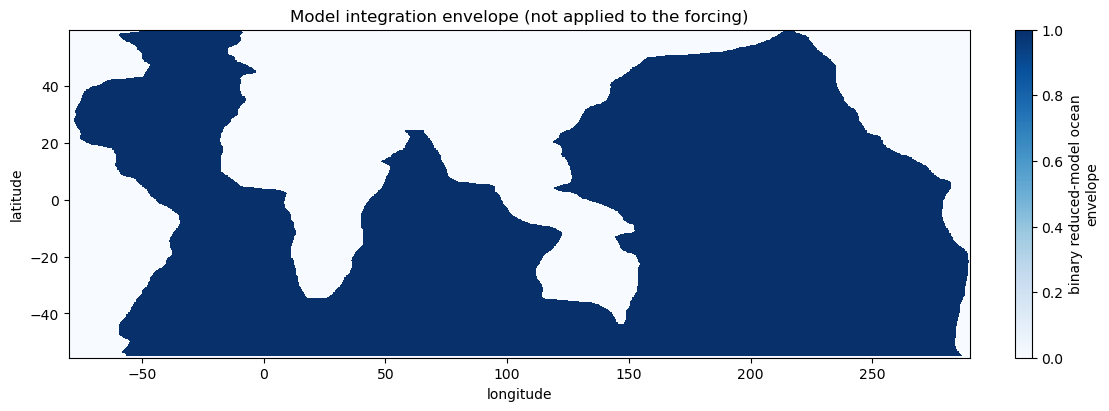

In [7]:
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
ocean_mask.astype(np.int8).plot.pcolormesh(
    ax=ax, x="longitude", y="latitude", cmap="Blues", vmin=0, vmax=1
)
ax.set_title("Model integration envelope (not applied to the forcing)")
plt.show()

## Identify land and unresolved internal islands with GEBCO

GEBCO land presence is aggregated over the complete footprint of every ERA5 cell. Connected land components entering a guard band around the model integration envelope are classified as coastline. The remaining components are unresolved internal islands and are eligible for optional inpainting.

This classification affects preprocessing only. No land or ocean mask is passed to the model.

In [8]:
def gebco_presence_on_grid(path, target_latitude, target_longitude):
    """Return ERA5-cell land presence aggregated from native GEBCO.

    Each target cell is represented by all GEBCO samples in its rectangular
    footprint. Longitude windows wrap periodically so the unwrapped model grid
    can include both negative Atlantic and greater-than-180 Pacific values.
    """
    latitude_step = float(np.diff(target_latitude).min())
    longitude_step = float(np.diff(target_longitude).min())
    land = np.zeros((target_latitude.size, target_longitude.size), dtype=bool)

    with NetCDFDataset(path) as source:
        source_latitude = np.asarray(source.variables["lat"][:], dtype=float)
        source_longitude = np.asarray(source.variables["lon"][:], dtype=float)
        elevation = source.variables["elevation"]
        extended_longitude = np.concatenate(
            (source_longitude - 360.0, source_longitude, source_longitude + 360.0)
        )
        source_longitude_size = source_longitude.size
        wrapped_target = (target_longitude + 180.0) % 360.0 - 180.0
        longitude_windows = []
        for value in wrapped_target:
            lower = np.searchsorted(
                extended_longitude, value - longitude_step / 2.0, side="left"
            )
            upper = np.searchsorted(
                extended_longitude, value + longitude_step / 2.0, side="left"
            )
            longitude_windows.append(
                np.arange(lower, upper, dtype=int) % source_longitude_size
            )
        window_sizes = {window.size for window in longitude_windows}
        if len(window_sizes) != 1:
            raise RuntimeError("GEBCO longitude aggregation windows are inconsistent")
        longitude_windows = np.stack(longitude_windows)

        for row, value in enumerate(target_latitude):
            lower = np.searchsorted(
                source_latitude, value - latitude_step / 2.0, side="left"
            )
            upper = np.searchsorted(
                source_latitude, value + latitude_step / 2.0, side="left"
            )
            band = np.asarray(elevation[lower:upper, :])
            if band.size == 0:
                raise RuntimeError(f"GEBCO does not cover latitude {value}")
            land_by_longitude = np.any(band >= 0.0, axis=0)
            land[row] = land_by_longitude[longitude_windows].any(axis=1)

    return land


land_presence = gebco_presence_on_grid(GEBCO_PATH, latitude, longitude)
eight_connected = np.ones((3, 3), dtype=bool)
cardinal_connected = np.array(
    [[False, True, False], [True, True, True], [False, True, False]]
)
land_inside_ocean = land_presence & active_layer
land_labels, _ = ndimage.label(land_inside_ocean, structure=eight_connected)
boundary_guard = active_layer & ~ndimage.binary_erosion(
    active_layer,
    structure=eight_connected,
    iterations=ISLAND_HALO_CELLS + 1,
    border_value=0,
)
coastal_labels = np.unique(land_labels[boundary_guard & (land_labels > 0)])
internal_land = land_inside_ocean & ~np.isin(land_labels, coastal_labels)
_, internal_island_count = ndimage.label(internal_land, structure=eight_connected)

if INPAINT_ISLANDS:
    ocean_interior = ndimage.binary_erosion(
        active_layer, structure=cardinal_connected, iterations=1, border_value=0
    )
    island_mask = (
        ndimage.binary_dilation(
            internal_land,
            structure=eight_connected,
            iterations=ISLAND_HALO_CELLS,
        )
        & ocean_interior
    )
    if np.any(island_mask & ~active_layer):
        raise AssertionError("Island inpainting mask extends outside the model envelope")
    if np.any(internal_land & ~island_mask):
        raise AssertionError("An internal island was clipped from the inpainting mask")
    if np.any(
        ndimage.binary_dilation(island_mask, structure=cardinal_connected)
        & ~active_layer
    ):
        raise AssertionError("Island inpainting lacks a finite ocean donor ring")
else:
    island_mask = np.zeros_like(active_layer)

_, island_component_count = ndimage.label(island_mask, structure=eight_connected)
print(
    f"GEBCO land cells: {land_presence.sum():,}; "
    f"internal islands: {internal_island_count:,}; "
    f"inpainting cells/components: {island_mask.sum():,}/{island_component_count:,}"
)

GEBCO land cells: 208,055; internal islands: 427; inpainting cells/components: 32,421/99


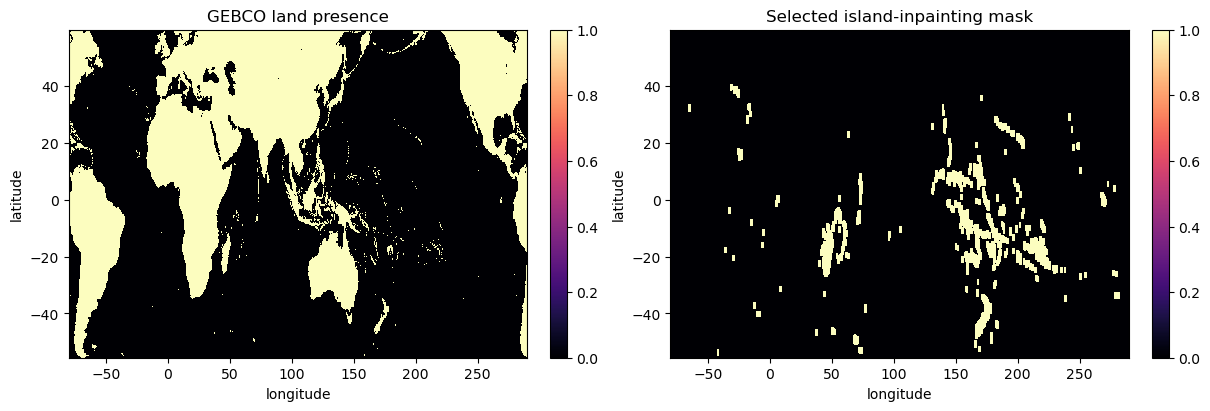

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, values, title in (
    (axes[0], land_presence, "GEBCO land presence"),
    (axes[1], island_mask, "Selected island-inpainting mask"),
):
    xr.DataArray(
        values,
        dims=("latitude", "longitude"),
        coords={"latitude": latitude, "longitude": longitude},
    ).plot.pcolormesh(ax=ax, x="longitude", y="latitude", cmap="magma")
    ax.set_title(title)
plt.show()

## Optional bounded island inpainting

When enabled, each island/halo cell receives a positive-weight Gaussian average of finite nearby ocean stress. Normalisation makes every fill a convex combination of donors, so it cannot overshoot their extrema. When disabled, the original ERA5 stress is retained unchanged, including over islands.

The Dask implementation processes twelve months and both stress components per task and preserves every original value outside the selected island mask.

In [10]:
def gaussian_inpainting_weights(mask, donor_mask, sigma_cells):
    """Return a finite normalisation field and sufficient filter radius."""
    if mask.ndim != 2 or donor_mask.shape != mask.shape or not np.any(mask):
        raise ValueError("mask and donor_mask must be matching two-dimensional arrays")
    if np.any(mask & donor_mask) or not np.any(donor_mask):
        raise ValueError("donors must be non-empty and outside the inpainting mask")
    if not np.isfinite(sigma_cells) or sigma_cells <= 0.0:
        raise ValueError("sigma_cells must be positive")

    maximum_distance = float(
        ndimage.distance_transform_edt(~donor_mask)[mask].max()
    )
    radius = int(np.ceil(maximum_distance)) + ISLAND_HALO_CELLS
    denominator = ndimage.gaussian_filter(
        donor_mask.astype(np.float64),
        sigma=sigma_cells,
        radius=radius,
        mode="constant",
        cval=0.0,
    )
    if np.any(denominator[mask] <= np.finfo(np.float64).tiny):
        raise ValueError("Gaussian support does not reach every inpainting cell")
    return denominator, radius


def inpaint_stress_block(
    values,
    mask,
    donor_mask,
    denominator,
    sigma_cells,
    radius,
):
    """Fill one vector-stress block with bounded Gaussian donor averages."""
    if values.ndim != 4 or values.shape[-2:] != mask.shape:
        raise ValueError("stress block must have time, component, and mask dimensions")
    donor_values = values[..., donor_mask]
    if not np.all(np.isfinite(donor_values)):
        raise ValueError("ocean stress donors must be finite")

    numerator = ndimage.gaussian_filter(
        np.where(donor_mask[None, None, :, :], values, 0.0),
        sigma=sigma_cells,
        radius=radius,
        axes=(-2, -1),
        mode="constant",
        cval=0.0,
    )
    interpolated = np.zeros_like(numerator)
    np.divide(
        numerator,
        denominator[None, None, :, :],
        out=interpolated,
        where=denominator[None, None, :, :] > np.finfo(np.float64).tiny,
    )
    filled_values = interpolated[..., mask]
    donor_minimum = donor_values.min(axis=-1)[..., None]
    donor_maximum = donor_values.max(axis=-1)[..., None]
    tolerance = 16.0 * np.finfo(values.dtype).eps * np.maximum(
        1.0, np.maximum(abs(donor_minimum), abs(donor_maximum))
    )
    if (
        not np.all(np.isfinite(filled_values))
        or np.any(filled_values < donor_minimum - tolerance)
        or np.any(filled_values > donor_maximum + tolerance)
    ):
        raise RuntimeError("bounded island interpolation violated donor extrema")

    output = values.copy()
    output[..., mask] = filled_values.astype(values.dtype, copy=False)
    return output


def lazy_inpainted_stress(values, mask, donor_mask, time_chunk=12):
    """Return a lazy bounded interpolation of vector stress over islands."""
    denominator, radius = gaussian_inpainting_weights(
        mask, donor_mask, INPAINT_SIGMA_CELLS
    )
    rechunked = values.rechunk({0: time_chunk, 1: -1, 2: -1, 3: -1})
    delayed_blocks = rechunked.to_delayed().reshape(
        len(rechunked.chunks[0]), 1, 1, 1
    )[:, 0, 0, 0]
    output_blocks = []
    for block, count in zip(delayed_blocks, rechunked.chunks[0]):
        filled = delayed(inpaint_stress_block)(
            block,
            mask,
            donor_mask,
            denominator,
            INPAINT_SIGMA_CELLS,
            radius,
        )
        output_blocks.append(
            da.from_delayed(
                filled,
                shape=(count, values.shape[1], values.shape[2], values.shape[3]),
                dtype=values.dtype,
            )
        )
    return da.concatenate(output_blocks, axis=0)


stress = da.stack(
    (
        winds.avg_iews.transpose("time", "latitude", "longitude").data,
        winds.avg_inss.transpose("time", "latitude", "longitude").data,
    ),
    axis=1,
)
if INPAINT_ISLANDS:
    stress_donor_mask = active_layer & ~land_presence & ~island_mask
    processed_stress = lazy_inpainted_stress(
        stress, island_mask, stress_donor_mask
    )
else:
    processed_stress = stress

winds_islands = xr.Dataset(
    {
        "avg_iews": (
            ("time", "latitude", "longitude"), processed_stress[:, 0]
        ),
        "avg_inss": (
            ("time", "latitude", "longitude"), processed_stress[:, 1]
        ),
    },
    coords={
        "time": winds.time,
        "latitude": winds.latitude,
        "longitude": winds.longitude,
    },
)
winds_islands

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 246, latitude: 462, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.5 -55.25 -55.0 ... 59.25 59.5 59.75
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    avg_iews   (time, latitude, longitude) float32 673MB dask.array<chunksize=(12, 462, 1481), meta=np.ndarray>
    avg_inss   (time, latitude, longitude) float32 673MB dask.array<chunksize=(12, 462, 1481), meta=np.ndarray>

## Optional taper at GEBCO land boundaries

When enabled, stress is exactly zero on every remaining GEBCO land cell and rises smoothly to its full value over `TAPER_WIDTH_DEGREES` of adjacent ocean. Internal islands selected for inpainting are removed from this land mask. When tapering is disabled, no multiplier is applied and ERA5 land stress is retained except where island inpainting was explicitly requested.

In [11]:
land_for_taper = land_presence.copy()
if INPAINT_ISLANDS:
    land_for_taper[internal_land] = False

if TAPER_LAND_BOUNDARIES:
    distance_to_land = ndimage.distance_transform_edt(
        ~land_for_taper,
        sampling=(latitude_step, longitude_step),
    )
    taper_values = smooth_ramp(distance_to_land / TAPER_WIDTH_DEGREES)
else:
    taper_values = np.ones_like(land_for_taper, dtype=float)

land_taper = xr.DataArray(
    taper_values.astype(np.float32),
    dims=("latitude", "longitude"),
    coords={"latitude": latitude, "longitude": longitude},
    name="land_taper",
    attrs={
        "long_name": "optional smooth stress taper at GEBCO land boundaries",
        "enabled": int(TAPER_LAND_BOUNDARIES),
        "taper_width_degrees": TAPER_WIDTH_DEGREES,
    },
)
if float(land_taper.min()) < 0.0 or float(land_taper.max()) > 1.0:
    raise AssertionError("Land taper must remain within [0, 1]")
if TAPER_LAND_BOUNDARIES and np.any(taper_values[land_for_taper] != 0.0):
    raise AssertionError("Tapered land cells must be exactly zero")
if not TAPER_LAND_BOUNDARIES and not np.all(taper_values == 1.0):
    raise AssertionError("Disabled taper must be exactly one everywhere")

winds_preprocessed = winds_islands * land_taper
# Float64 climatologies avoid cancellation residuals when the final transport
# anomalies are stored as float32.
winds_preprocessed_float64 = winds_preprocessed.astype(np.float64)
winds_anomaly = (
    winds_preprocessed_float64
    - winds_preprocessed_float64.mean("time")
)
winds_anomaly

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 246, latitude: 462, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.5 -55.25 -55.0 ... 59.25 59.5 59.75
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    avg_iews   (time, latitude, longitude) float64 1GB dask.array<chunksize=(12, 462, 1481), meta=np.ndarray>
    avg_inss   (time, latitude, longitude) float64 1GB dask.array<chunksize=(12, 462, 1481), meta=np.ndarray>
Attributes:
    long_name:            optional smooth stress taper at GEBCO land boundaries
    enabled:              0
    taper_width_degrees:  2.0

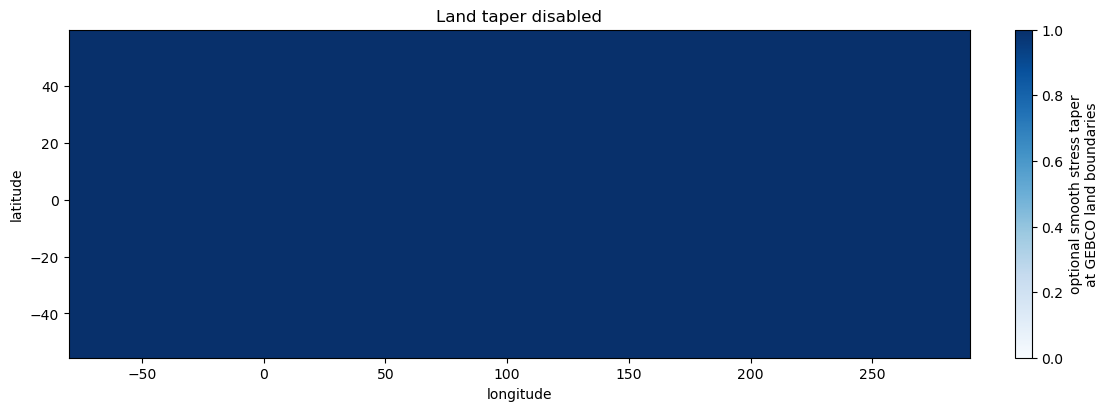

In [12]:
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
land_taper.plot.pcolormesh(
    ax=ax, x="longitude", y="latitude", cmap="Blues", vmin=0.0, vmax=1.0
)
ax.set_title(
    "GEBCO land taper" if TAPER_LAND_BOUNDARIES else "Land taper disabled"
)
plt.show()

## Convert the complete stress field to vector Ekman transport

No model-geometry mask is applied. The optionally preprocessed stress anomaly is converted at every latitude--longitude cell using

$$M_{\mathrm{Ek},x}=\frac{I_\gamma\tau_y}{\rho_0},\qquad M_{\mathrm{Ek},y}=-\frac{I_\gamma\tau_x}{\rho_0}.$$

The model can therefore differentiate the supplied field naively and defer use of the isobaths until its regional interior integrals. Any taper-generated pumping or retained land stress is an explicit property of this forcing product.

In [13]:
inverse_f = coriolis(winds_anomaly.latitude) / (
    coriolis(winds_anomaly.latitude) ** 2 + gamma**2
)
tau_x = winds_anomaly.avg_iews
tau_y = winds_anomaly.avg_inss

M_Ek_x_raw = tau_y * inverse_f / RHO_0
M_Ek_y_raw = -tau_x * inverse_f / RHO_0
M_Ek_x = (
    M_Ek_x_raw - M_Ek_x_raw.mean("time")
).astype(np.float32).rename("M_Ek_x")
M_Ek_y = (
    M_Ek_y_raw - M_Ek_y_raw.mean("time")
).astype(np.float32).rename("M_Ek_y")
T_N = (scotia_anomaly * 1e6).astype(np.float64).rename("T_N")

M_Ek_x.attrs = {
    "units": "m2 s-1",
    "long_name": "eastward Ekman transport anomaly",
    "positive": "eastward",
}
M_Ek_y.attrs = {
    "units": "m2 s-1",
    "long_name": "northward Ekman transport anomaly",
    "positive": "northward",
}
T_N.attrs = {
    "units": "m3 s-1",
    "long_name": "total northern Atlantic transport anomaly from SCOTIA",
    "positive": "northward",
    "latitude_degrees_north": ATLANTIC_NORTH,
}

forcing = xr.Dataset({"M_Ek_x": M_Ek_x, "M_Ek_y": M_Ek_y, "T_N": T_N})
forcing = forcing.transpose("time", "latitude", "longitude", missing_dims="ignore")
forcing.attrs.update(
    title="V4 configurable global ERA5 Ekman transport and SCOTIA forcing anomalies",
    forcing_version=4,
    source_wind_stress="ERA5 monthly mean eastward/northward turbulent surface stress",
    source_northern_transport="SCOTIA monthly-mean overturning diagnostics MOC",
    source_geometry=ISOBATH_PATH.name,
    source_bathymetry=GEBCO_PATH.name,
    anomaly_reference="time mean over the common 2004-01 to 2024-06 monthly record",
    rho_0_kg_m3=RHO_0,
    g_prime_m_s2=G_PRIME,
    active_layer_depth_m=H,
    equatorial_cap_latitude_degrees=phi_c,
    equatorial_gamma_s_1=gamma,
    spatial_support="complete finite rectangular grid; model geometry not applied",
    generated_by="notebooks/input_generation/construct_forcing_dataset_v4.ipynb",
    taper_land_boundaries=int(TAPER_LAND_BOUNDARIES),
    taper_width_degrees=TAPER_WIDTH_DEGREES,
    taper_description=(
        "GEBCO land masked to zero with a smooth ocean transition"
        if TAPER_LAND_BOUNDARIES
        else "disabled; ERA5 stress retained over land except inpainted islands"
    ),
    inpaint_islands=int(INPAINT_ISLANDS),
    island_preprocessing=(
        "bounded Gaussian average of ERA5 ocean stress over GEBCO-resolved internal land"
        if INPAINT_ISLANDS
        else "disabled; original ERA5 stress retained over islands"
    ),
    island_mask_cell_count=int(island_mask.sum()),
    island_mask_component_count=int(island_component_count),
    island_halo_cells=ISLAND_HALO_CELLS,
    island_inpainting_sigma_cells=INPAINT_SIGMA_CELLS,
    spatial_halo_cells=SPATIAL_HALO_CELLS,
)
forcing

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 246, latitude: 462, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.5 -55.25 -55.0 ... 59.25 59.5 59.75
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    M_Ek_x     (time, latitude, longitude) float32 673MB dask.array<chunksize=(12, 462, 1481), meta=np.ndarray>
    M_Ek_y     (time, latitude, longitude) float32 673MB dask.array<chunksize=(12, 462, 1481), meta=np.ndarray>
    T_N        (time) float64 2kB dask.array<chunksize=(246,), meta=np.ndarray>
Attributes: (12/24)
    title:                            V4 configurable global ERA5 Ekman trans...
    forcing_version:                  4
    source_wind_stress:               ERA5 monthly mean eastward/northward tu...
    source_northern_transport:        SCOTIA monthly-mean overturning diagnos...
    source_geometry:                  global_isobath_GEBCO_1000m.nc
    source_bathymetry:                GEBCO_2026_sub_ice.nc
    ...                               ...
    island_preprocessing:             bounded Gaussian average of ERA5 ocean ...
    island_mask_cell_count:           32421
    island_mask_component_count:      99
    island_halo_cells:                4
    island_inpainting_sigma_cells:    4.0
    spatial_halo_cells:               2

## Contract checks and export

The v4 contract requires finite Ekman transport over the entire rectangular grid. Checks also verify the selected preprocessing semantics: inpainting cannot alter values outside its mask, disabling inpainting preserves all raw stress, enabling tapering zeros the selected land cells, and disabling tapering applies no multiplier.

The result is written to an option-specific file and reopened to verify the complete finite-field contract, extrema, time convention, and provenance.

In [14]:
if set(forcing.data_vars) != {"M_Ek_x", "M_Ek_y", "T_N"}:
    raise AssertionError("Forcing dataset must contain exactly three variables")
for name in ("M_Ek_x", "M_Ek_y"):
    if forcing[name].dims != ("time", "latitude", "longitude"):
        raise AssertionError(f"Unexpected dimensions for {name}")
    if forcing[name].attrs["units"] != "m2 s-1":
        raise AssertionError(f"Unexpected units for {name}")
if forcing.T_N.dims != ("time",) or forcing.T_N.attrs["units"] != "m3 s-1":
    raise AssertionError("Unexpected T_N contract")
if forcing.T_N.attrs["latitude_degrees_north"] != ATLANTIC_NORTH:
    raise AssertionError("T_N has the wrong prescribed latitude")
if not forcing.time.equals(scotia.time):
    raise AssertionError("Forcing variables do not use the SCOTIA time grid")
expected_time = forcing.time.values.astype("datetime64[M]").astype("datetime64[ns]")
if not np.array_equal(forcing.time.values.astype("datetime64[ns]"), expected_time):
    raise AssertionError("Time coordinates must be the first day of each month")
month_number = forcing.time.values.astype("datetime64[M]").astype(np.int64)
if np.any(np.diff(month_number) != 1):
    raise AssertionError("Forcing months are not contiguous")
if not np.all(np.diff(forcing.latitude) > 0) or not np.all(np.diff(forcing.longitude) > 0):
    raise AssertionError("Spatial coordinates must be strictly increasing")
if not np.isclose(float(forcing.T_N.mean()), 0.0, atol=1e-8):
    raise AssertionError("T_N is not a zero-mean anomaly")

M_Ek_time_means_and_scales = dask.compute(
    abs(forcing.M_Ek_x.astype(np.float64).mean("time")).max(),
    abs(forcing.M_Ek_y.astype(np.float64).mean("time")).max(),
    abs(forcing.M_Ek_x).max(),
    abs(forcing.M_Ek_y).max(),
    np.isfinite(forcing.M_Ek_x).all(),
    np.isfinite(forcing.M_Ek_y).all(),
)
M_Ek_time_means = M_Ek_time_means_and_scales[:2]
M_Ek_scale = max(1.0, *map(float, M_Ek_time_means_and_scales[2:4]))
M_Ek_mean_tolerance = 16.0 * np.finfo(np.float32).eps * M_Ek_scale
if max(map(float, M_Ek_time_means)) >= M_Ek_mean_tolerance:
    raise AssertionError(f"M_Ek anomaly mean is too large: {M_Ek_time_means}")
if not all(map(bool, M_Ek_time_means_and_scales[4:])):
    raise AssertionError("V4 Ekman transports must be finite over the complete grid")

transport_limits = xr.Dataset(
    {
        f"{name}_minimum": forcing[name].min(("latitude", "longitude"))
        for name in ("M_Ek_x", "M_Ek_y")
    }
    | {
        f"{name}_maximum": forcing[name].max(("latitude", "longitude"))
        for name in ("M_Ek_x", "M_Ek_y")
    }
).compute()
if not all(np.all(np.isfinite(array)) for array in transport_limits.data_vars.values()):
    raise AssertionError("M_Ek spatial extrema must be finite at every time")
print(transport_limits)

raw_sample, island_sample, processed_sample = dask.compute(
    winds[["avg_iews", "avg_inss"]].isel(time=[0, -1]),
    winds_islands[["avg_iews", "avg_inss"]].isel(time=[0, -1]),
    winds_preprocessed[["avg_iews", "avg_inss"]].isel(time=[0, -1]),
)
for name in ("avg_iews", "avg_inss"):
    raw_values = raw_sample[name].values
    island_values = island_sample[name].values
    processed_values = processed_sample[name].values
    unchanged = ~island_mask if INPAINT_ISLANDS else np.ones_like(island_mask)
    if not np.array_equal(island_values[:, unchanged], raw_values[:, unchanged]):
        raise AssertionError(f"Island option unexpectedly changed {name} outside its mask")
    if TAPER_LAND_BOUNDARIES:
        if not np.all(processed_values[:, land_for_taper] == 0.0):
            raise AssertionError(f"Tapered {name} is nonzero on selected land")
    elif not np.array_equal(processed_values, island_values):
        raise AssertionError(f"Disabled taper unexpectedly changed {name}")

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
temporary_path = OUTPUT_PATH.with_name(f"{OUTPUT_PATH.stem}.tmp{OUTPUT_PATH.suffix}")
if temporary_path.exists():
    temporary_path.unlink()

n_time = forcing.sizes["time"]
encoding = {
    "time": {
        "dtype": "int32",
        "units": "days since 1970-01-01",
        "calendar": "proleptic_gregorian",
        "_FillValue": None,
    },
    "M_Ek_x": {
        "dtype": "float32",
        "compression": "gzip",
        "compression_opts": 2,
        "shuffle": True,
        "chunksizes": (n_time, 16, 64),
        "_FillValue": None,
    },
    "M_Ek_y": {
        "dtype": "float32",
        "compression": "gzip",
        "compression_opts": 2,
        "shuffle": True,
        "chunksizes": (n_time, 16, 64),
        "_FillValue": None,
    },
    "T_N": {"dtype": "float64", "_FillValue": None},
}
write = forcing.to_netcdf(
    temporary_path, engine="h5netcdf", encoding=encoding, compute=False
)
with dask.config.set(scheduler="threads", num_workers=4), ProgressBar():
    write.compute()
temporary_path.replace(OUTPUT_PATH)
print(f"Wrote {OUTPUT_PATH} ({OUTPUT_PATH.stat().st_size / 1e9:.2f} GB)")

<xarray.Dataset> Size: 6kB
Dimensions:         (time: 246)
Coordinates:
  * time            (time) datetime64[ns] 2kB 2004-01-01 ... 2024-06-01
Data variables:
    M_Ek_x_minimum  (time) float32 984B -24.06 -28.29 -36.73 ... -13.73 -13.12
    M_Ek_y_minimum  (time) float32 984B -17.01 -14.69 -12.38 ... -16.42 -29.16
    M_Ek_x_maximum  (time) float32 984B 12.73 12.24 12.91 ... 11.14 27.49 37.46
    M_Ek_y_maximum  (time) float32 984B 21.09 24.83 27.37 ... 15.63 26.5 25.05


[                                        ] | 0% Completed | 83.46 us

[                                        ] | 0% Completed | 195.60 ms

[                                        ] | 0% Completed | 508.46 ms

[                                        ] | 1% Completed | 610.46 ms

...

[####################################### ] | 99% Completed | 234.40 s

[####################################### ] | 99% Completed | 234.51 s

[####################################### ] | 99% Completed | 234.61 s

[########################################] | 100% Completed | 234.72 s

Wrote /private/tmp/MOCAdjustmentTheory-issue39/data/untracked/forcing/global_ERA5_SCOTIA_forcing_v4_taper-0_islands-1.nc (1.05 GB)


In [15]:
with xr.open_dataset(OUTPUT_PATH, engine="h5netcdf", chunks={}) as exported:
    if set(exported.data_vars) != {"M_Ek_x", "M_Ek_y", "T_N"}:
        raise AssertionError("Exported file has the wrong variables")
    if exported.sizes != forcing.sizes:
        raise AssertionError("Exported file has the wrong dimensions")
    if exported.T_N.attrs.get("latitude_degrees_north") != ATLANTIC_NORTH:
        raise AssertionError("Exported T_N latitude metadata was not preserved")
    if exported.attrs.get("forcing_version") != 4:
        raise AssertionError("Exported forcing version is not v4")
    if bool(exported.attrs.get("taper_land_boundaries")) != TAPER_LAND_BOUNDARIES:
        raise AssertionError("Exported taper option is incorrect")
    if bool(exported.attrs.get("inpaint_islands")) != INPAINT_ISLANDS:
        raise AssertionError("Exported inpainting option is incorrect")
    expected_time = exported.time.values.astype("datetime64[M]").astype("datetime64[ns]")
    if not np.array_equal(exported.time.values.astype("datetime64[ns]"), expected_time):
        raise AssertionError("Exported time coordinates are not month starts")
    month_number = exported.time.values.astype("datetime64[M]").astype(np.int64)
    if np.any(np.diff(month_number) != 1):
        raise AssertionError("Exported forcing months are not contiguous")
    sample = exported[["M_Ek_x", "M_Ek_y"]].isel(time=[0, -1]).load()
    for name in sample.data_vars:
        if not np.all(np.isfinite(sample[name].values)):
            raise AssertionError(f"Exported {name} is not finite over the complete grid")
    exported_transport_limits = xr.Dataset(
        {
            f"{name}_minimum": exported[name].min(("latitude", "longitude"))
            for name in ("M_Ek_x", "M_Ek_y")
        }
        | {
            f"{name}_maximum": exported[name].max(("latitude", "longitude"))
            for name in ("M_Ek_x", "M_Ek_y")
        }
    ).compute()
    xr.testing.assert_allclose(exported_transport_limits, transport_limits)
    if bool(exported.T_N.isnull().any().compute()):
        raise AssertionError("Exported T_N contains missing values")
    if "complete finite rectangular grid" not in exported.attrs.get(
        "spatial_support", ""
    ):
        raise AssertionError("Exported finite-field provenance is missing")
    print(exported)
    print("schema, options, provenance, and complete finite field verified")

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 246, latitude: 462, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.5 -55.25 -55.0 ... 59.25 59.5 59.75
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    M_Ek_x     (time, latitude, longitude) float32 673MB dask.array<chunksize=(246, 16, 64), meta=np.ndarray>
    M_Ek_y     (time, latitude, longitude) float32 673MB dask.array<chunksize=(246, 16, 64), meta=np.ndarray>
    T_N        (time) float64 2kB dask.array<chunksize=(246,), meta=np.ndarray>
Attributes: (12/24)
    title:                            V4 configurable global ERA5 Ekman trans...
    forcing_version:                  4
    source_wind_stress:               ERA5 monthly mean eastward/northward tu...
    source_northern_transport:        SCOTIA monthly-mean overturning diagnos...
    source_geometry:                  global_